We want to understand regression as a statistical model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

We generate the x once and for all. Why? Because we are interested in the conditional expectation E[y|x]. In some other instances, x is random too (prediction, causality analysis)

In [24]:
n = 87
x = np.random.normal(5, 2, n)

In [25]:
e = np.random.normal(0, 1, n)
y = -1 + 2*x + e

Now we estimate using OLS. Estimated beta change at each generation.

In [4]:
import statsmodels.api as sm

X = sm.add_constant(x)

# Fit the OLS model
model = sm.OLS(y, X).fit()
print(model.params[0],model.params[1])

-0.8599231191426353 1.972247277449402


What is the distribution of the parameters?

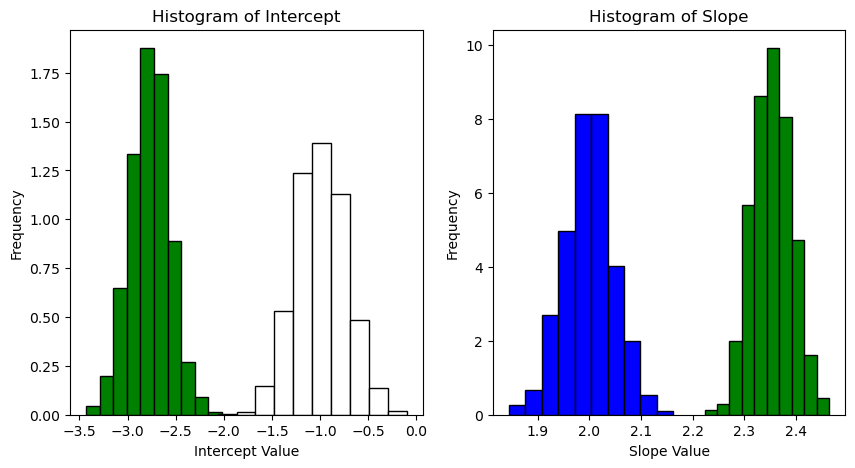

In [23]:
n = 87
x = np.random.normal(5, 2, n)
X = sm.add_constant(x)

nsim = 1000
beta = []
beta1 = []
# Perform the estimation nsim times
for i in range(nsim):
    e = np.random.normal(0, 1, n)
    e1 = np.sqrt(3)*np.random.uniform(-1, 1, n) # non normal
    e1 = np.random.exponential(1,n)-1 # skewed distribution
    e1 = np.sqrt(12)*np.random.uniform(0, 1, n) # non-zero mean
    e1 = np.random.exponential(1,n) # non-zero mean
    e1 = np.sqrt(3)/np.sqrt(29)*x*np.random.uniform(-1, 1, n) # heteroskedasticity
    e1 = 1/np.sqrt(2)*((x-5)/2 + np.sqrt(3)*np.random.uniform(-1, 1, n)) # endogeneity
    y = -1 + 2*x + e
    y1 = -1 + 2*x + e1
    # Fit the OLS model
    model = sm.OLS(y, X).fit()
    model1 = sm.OLS(y1, X).fit()
    # Store the results
    beta.append(model.params)
    beta1.append(model1.params)

beta = np.array(beta) # pampering python for no reason
beta1 = np.array(beta1)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(beta1[:, 0], color='green', edgecolor='black', density=True)
plt.hist(beta[:, 0], color='white', edgecolor='black', density=True)
plt.title('Histogram of Intercept')
plt.xlabel('Intercept Value')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(beta1[:, 1],  color='green', edgecolor='black', density=True)
plt.hist(beta[:, 1],  color='blue', edgecolor='black', density=True)
plt.title('Histogram of Slope')
plt.xlabel('Slope Value')
plt.ylabel('Frequency')

#plt.tight_layout()
plt.show()